# Generalized Integrate-and-Fire Neuron

In [1]:
#!pip install ANNarchy

This notebook explores the generalized Integrate-and-Fire neuron model being used for reproducing measured data.

Code based on:

> Schwalger, T., Deger, M., Gerstner, w. (2017). Towards a theory of cortical columns: From spiking neurons to interacting neural populations of finite size. PLoS Comput Biol. 2017;13(4):e1005507


In [2]:
import matplotlib.pyplot as plt
import numpy

import ANNarchy as ann

ANNarchy 5.0 (5.0.3) on linux (posix).


The generalized Integrate-and-Fire (GIF) neuron is defined by the following equations:

$$
\begin{aligned}
    \tau_m \frac{du}{dt} &= -u + u_r + R*I_{ext} \\
    \tau_v \frac{dv}{dt} &= -(v-u_{th})
\end{aligned}
$$

Spike emission is the result of a stochastic process, where the threshold $\lambda$, also called hazard-rate, follows the difference between the membrane potential $u$ and an adaptive threshold $v$:

$$
    \lambda = c * exp(\frac{u-v}{\delta_{u}})
$$

After emitting a spike event, the membrane potential $u$ is reseted and the adaptive threshold $v$ is increased:

$$
\begin{aligned}
    u &\leftarrow u_r \\
    v &\leftarrow v + \frac{J_v}{\tau_v}
\end{aligned}
$$


The GIF neuron model is pre-implemented in ANNarchy, but could be implemented like the following:

```python
GIF = ann.Neuron(
    parameters = dict(
        # membrane potential
        C_m         =  250.0,
        tau_m       =   10.0,
        R           =   0.04, # R = tau/C = 10ms / 250pA
        # spiking behavior
        tau_v       = 1000.0,
        J_v         = 1000.0,
        u_r         =  -65.0,
        u_th        =  -50.0,
        # escape rate
        c           =   10.0,
        delta_u     =    5.0,
        # synaptic inputs
        I_ext       =  375.0
    ),
    equations = [
        # membrane potential
        Variable("tau_m * du/dt = -u + u_r + R*I_ext", init='u_r'),
        # adaptive spike threshold, v is incremented by each spike, otherwise decays toward u_t
        Variable("tau_v * dv/dt = -(v-u_th)", init='u_th'),
        # escape rate in Hz, resp. spikes/s
        Variable("Lambda = c * exp((u-v)/delta_u)"),
        # Note: we need to map from ms -> s, that it fits to rate in Hz
        Variable("p = Uniform(0.0, 1.0) * 1000.0 / dt"),
    ],
    spike = "p < Lambda",
    reset = """
        u = u_r
        v += J_v / tau_v
    """
)
```
However, for the following we want to use a different parameterization from the above mentioned article. This refers mainly to the value range for the membrane potential and consequently the spike threshold. However, the parameters can be easily changed:

In [3]:
net = ann.Network()

# we adapt some of the default parameters for this example
mod_GIF = ann.GIF_curr(
    u_r     =   25.0,
    u_th    =   10.0,
    c       =   10.0,
    delta_u =    5.0,
    I_ext   =    0.0,
    current = ""
)

Using this adapted neuron type, we can now create our population:

In [4]:
# create the population
P = net.create(500, neuron=mod_GIF)
P.u = 15.0

# select only one neuron
m = net.monitor(P[15], ["u", "v", "spike"])

# record spikes of all neurons
m2 = net.monitor(P, "spike")

net.compile()


Compiling network 1... 

OK


# Model Dynamics

A full description of the model can be found in the referenced article. For this notebook we want to take a short look on the model dynamics using two different input strengths. The first condition should result in a low activity, while the second condition leads to higher activity. Please remind, that this input current $I_{ext}$ is the only input to the neurons in this notebook, as no connections exists between the neurons.

In [5]:
# just for logging
input_signal = numpy.zeros(600)

# -> mu = 15 mv
P.I_ext = (15 - P.u_r)/P.R
net.simulate(300)
input_signal[:300] = P.I_ext

# -> mu = 30 mv
P.I_ext = (30 - P.u_r)/P.R
net.simulate(300)
input_signal[300:] = P.I_ext

Text(0.5, 0, 'biological time [ms]')

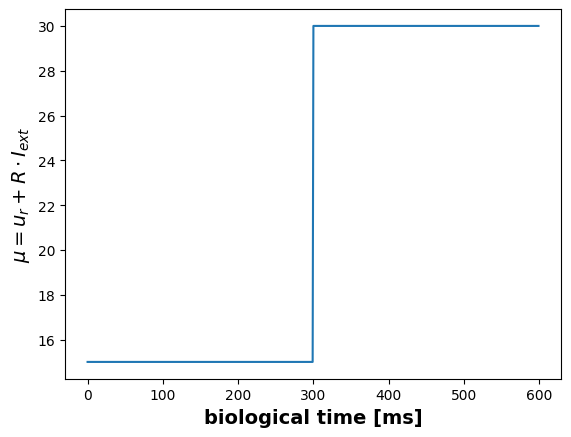

In [6]:
plt.figure()
plt.plot(P.u_r + P.R * input_signal)
plt.ylabel(r"$\mu = u_r + R \cdot I_{ext}$", fontsize=14, fontweight="bold")
plt.xlabel("biological time [ms]", fontsize=14, fontweight="bold")

## Single Neuron Behavior

The below plot visualizes the membrane potential $u$ of a single neuron.

Text(0.5, 0, 'biological time [ms]')

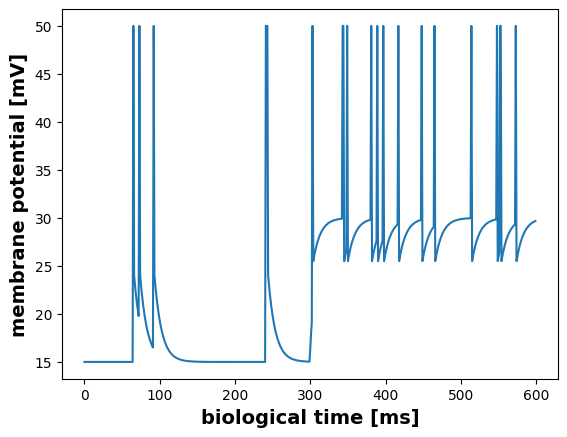

In [7]:
plt.figure()
u_data = m.get("u")
spikes = m.get("spike")[15]
u_data[spikes] = 50   # arbitrary value to highlight the spike
plt.plot(u_data)
plt.ylabel("membrane potential [mV]", fontsize=14, fontweight="bold")
plt.xlabel("biological time [ms]", fontsize=14, fontweight="bold")

Contrary to the standard leaky Integrate-and-Fire neuron, the GIF model has an adaptive threshold $v$, which is incremented by each emitted spike event.

Text(0.5, 0, 'biological time [ms]')

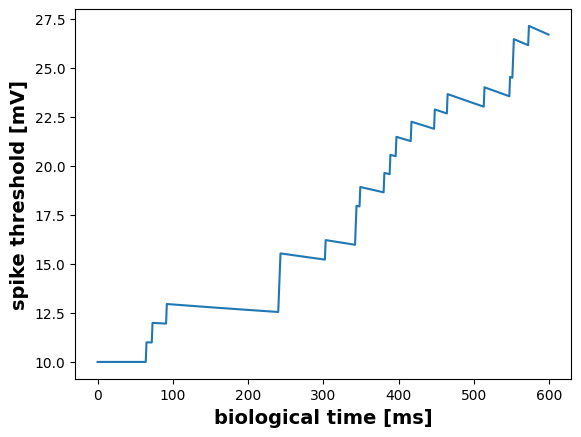

In [8]:
plt.figure()
v_data = m.get("v")
plt.plot(v_data)
plt.ylabel("spike threshold [mV]", fontsize=14, fontweight="bold")
plt.xlabel("biological time [ms]", fontsize=14, fontweight="bold")

## Group of Neurons

In [9]:
spikes = m2.get("spike")

Text(0.5, 0, 'biological time [ms]')

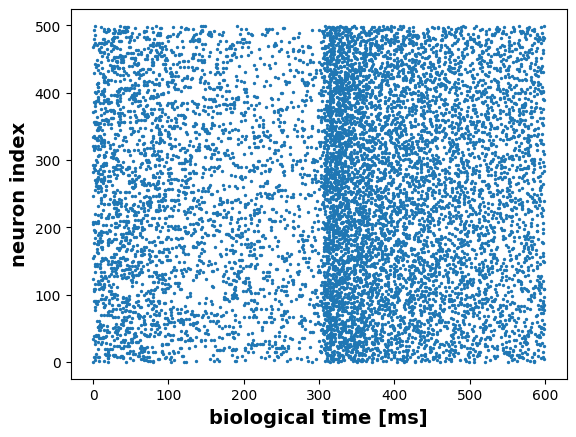

In [10]:
t, n = m2.raster_plot(spikes)
plt.scatter(t, n, s=2)
plt.ylabel("neuron index", fontsize=14, fontweight="bold")
plt.xlabel("biological time [ms]", fontsize=14, fontweight="bold")

For analysis we could either use a histogram depicting the amount of spikes in each time step,

Text(0.5, 0, 'biological time [ms]')

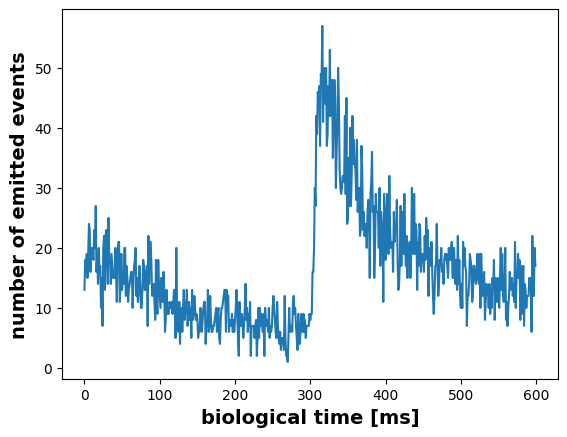

In [11]:
fr = m2.histogram(spikes)
plt.plot(fr)

plt.ylabel("number of emitted events", fontsize=14, fontweight="bold")
plt.xlabel("biological time [ms]", fontsize=14, fontweight="bold")

or an moving average across a fixed time window, in this case one millisecond.

Text(0.5, 0, 'biological time [ms]')

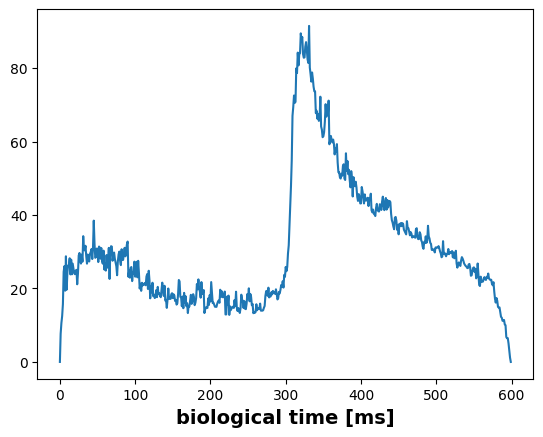

In [12]:
smooth_fr = m2.smoothed_rate(spikes, 1.0) # 1ms window
plt.plot(numpy.mean(smooth_fr, axis=0))
plt.xlabel("biological time [ms]", fontsize=14, fontweight="bold")